# Used Vehicle Price Prediction: Data Cleaning & Exploratory Data Analysis (EDA)

## Project Overview
The secondary car market is complex and influenced by a variety of factors including brand perception, vehicle age, mileage, and physical condition. This project aims to build a robust machine learning pipeline to predict vehicle prices accurately using a dataset of Craigslist listings.

### Objectives
1. **Data Sanitization**: Clean a large, noisy dataset by handling missing values and removing unrealistic entries.
2. **Feature Engineering**: Derive meaningful predictors from raw data (e.g., converting production years to vehicle age).
3. **Outlier Detection**: Employ both statistical and algorithmic methods to ensure high-quality training data.
4. **Exploratory Analysis**: Understand the distribution of variables and their correlation with price.

# Vehicles Dataset: Data Cleaning, EDA, and Feature Engineering

This notebook focuses on building a robust data preprocessing pipeline for a vehicles dataset. 
The goal is to clean raw data, handle inconsistencies, and prepare it for further analysis and modeling.

The workflow includes:

1. Efficient data loading using chunking to handle large CSV files without memory issues  
2. Initial data profiling and baseline visualizations to understand dataset structure and quality  
3. Data cleaning, including handling missing values, removing duplicates, fixing data types, and filtering invalid ranges  
4. Feature engineering to create meaningful features such as vehicle age and mileage per year  
5. Outlier detection using both statistical (IQR) and machine learning-based (Isolation Forest) approaches  
6. Basic leakage checks to ensure data integrity  
7. Log transformation analysis to reduce skewness in the target variable (price) and improve distribution

 IMPORT LIBRARIES:-


### 🌲 Theory: Multivariate Anomaly Detection
**Why Isolation Forest over IQR?**
- **Univariate (IQR)**: Only looks at one column at a time. It misses 'Contextual Outliers'.
- **Multivariate (Isolation Forest)**: Identifies anomalies based on feature interactions. 
  - *Example*: A 2022 Toyota Camry for $5,000 is 'normal' in price and 'normal' in year individually. However, the *combination* is highly anomalous. 
  - **Mechanism**: IF works by randomly selecting a feature and a split value. Anomalies are easier to 'isolate' and thus have shorter path lengths in the trees.


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import probplot
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import mean_squared_error, r2_score

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 200)

LOAD DATA

### Theory: Memory-Efficient Data Loading
**Why use Chunking?**
When working with large CSV files (millions of rows), loading the entire file into RAM using a standard `pd.read_csv()` can crash the system or cause severe slowdowns. 
- **The Solution**: We use the `chunksize` parameter to iterate through the file in blocks. 
- **Sampling Strategy**: To maintain speed during experimentation, we sample a fraction of each chunk. This provides a statistically representative subset of the data while keeping the memory footprint low.

In [2]:
DATA_PATH = 'vehicles.csv'
TARGET = 'price'

def load_large_csv(path, chunksize=250_000, sample_frac=0.3, max_rows=400_000, random_state=42):
    parts = []
    kept_rows = 0

    reader = pd.read_csv(
        path,
        chunksize=chunksize,
        low_memory=False,
        on_bad_lines='skip'
    )

    for i, chunk in enumerate(reader, start=1):
        if sample_frac < 1.0:
            chunk = chunk.sample(frac=sample_frac, random_state=random_state + i)

        parts.append(chunk)
        kept_rows += len(chunk)

        if max_rows is not None and kept_rows >= max_rows:
            break

    df = pd.concat(parts, ignore_index=True)

    if max_rows is not None and len(df) > max_rows:
        df = df.sample(n=max_rows, random_state=random_state).reset_index(drop=True)

    return df
df_raw = load_large_csv(DATA_PATH)
print(f'Loaded shape: {df_raw.shape}')
df_raw.head()

Loaded shape: (118142, 26)


,id,url,region,region_url,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,image_url,description,county,state,lat,long,posting_date
0,7313493645,https://topeka.craigslist.org/cto/d/tecumseh-f...,topeka,https://topeka.craigslist.org,6900,2008.0,lexus,rx 350,good,6 cylinders,gas,185700.0,clean,automatic,NaN,fwd,full-size,SUV,silver,https://images.craigslist.org/01313_bdyvF3GLvF...,"2008 Lexus RX 350, 185,700 miles. New Goodyear...",NaN,ks,39.021700,-95.537900,2021-04-27T14:40:41-0500
1,7312914885,https://stlouis.craigslist.org/ctd/d/wood-rive...,"st louis, MO",https://stlouis.craigslist.org,3950,2006.0,honda,odyssey,NaN,6 cylinders,gas,182738.0,clean,automatic,NaN,fwd,NaN,NaN,NaN,https://images.craigslist.org/00H0H_81EgcCfArh...,"Runs and drives great! ICE COLD A/C, hot heat,...",NaN,il,38.864300,-90.087500,2021-04-26T12:54:33-0500
2,7312005403,https://lasvegas.craigslist.org/ctd/d/las-vega...,las vegas,https://lasvegas.craigslist.org,29997,2016.0,mercedes-benz,gla,excellent,4 cylinders,gas,25025.0,clean,manual,WDCTG4EB3GJ201464,fwd,NaN,SUV,NaN,https://images.craigslist.org/01414_cy0ucMevAx...,2016 Mercedes-Benz GLA GLA 250 📲 ☎ Call or t...,NaN,nv,36.143633,-115.115449,2021-04-24T12:01:22-0700
3,7306671002,https://baltimore.craigslist.org/ctd/d/aberdee...,baltimore,https://baltimore.craigslist.org,6500,2012.0,ford,focus,excellent,4 cylinders,gas,111000.0,clean,automatic,NaN,fwd,NaN,NaN,black,https://images.craigslist.org/00n0n_dY5ShUIdlN...,2012 FORD FOCUS TITANIUM TOP LEVEL VERY NICE ...,NaN,md,39.510900,-76.180500,2021-04-14T11:12:33-0400
4,7316251051,https://atlanta.craigslist.org/atl/ctd/d/atlan...,atlanta,https://atlanta.craigslist.org,30990,2018.0,alfa-romeo,romeo stelvio ti sport suv,good,NaN,gas,30889.0,clean,other,ZASFAKNN6J7B64604,NaN,NaN,hatchback,blue,https://images.craigslist.org/00K0K_4Tmy43635F...,Carvana is the safer way to buy a car During t...,NaN,ga,33.750000,-84.390000,2021-05-03T12:21:11-0400


### Theory: Exploratory Data Profiling
Before cleaning, we must understand the 'Sparsity' and 'Cardinality' of the data.
- **df.info()**: Reveals data types (float vs object) and memory usage.
- **Null Analysis**: Helps us decide which columns are too empty to be useful (e.g., 'size' or 'vin') and which require imputation.
- **Categorical Cardinality**: Columns like 'model' have thousands of unique values, requiring specific encoding strategies later.

In [3]:
print(df_raw.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118142 entries, 0 to 118141
Data columns (total 26 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            118142 non-null  int64  
 1   url           118142 non-null  object 
 2   region        118142 non-null  object 
 3   region_url    118142 non-null  object 
 4   price         118142 non-null  int64  
 5   year          117796 non-null  float64
 6   manufacturer  113115 non-null  object 
 7   model         116641 non-null  object 
 8   condition     70601 non-null   object 
 9   cylinders     68969 non-null   object 
 10  fuel          117352 non-null  object 
 11  odometer      116941 non-null  float64
 12  title_status  115969 non-null  object 
 13  transmission  117442 non-null  object 
 14  VIN           72803 non-null   object 
 15  drive         81312 non-null   object 
 16  size          33758 non-null   object 
 17  type          91919 non-null   object 
 18  pain

### 🕳️ Theory: Missing Data Assessment

**Types of Missingness**:
1. **MCAR** (Missing Completely at Random): Missing values are unrelated to any variable
2. **MAR** (Missing at Random): Missingness depends on observed data
3. **MNAR** (Missing Not at Random): Missingness depends on unobserved data

**Why Count Missing Values?**
- Determines imputation strategy (mean/median/mode vs. deletion)
- High missingness (>40%) may warrant dropping the feature entirely
- Identifies data quality issues early


In [4]:
print(df_raw.isnull().sum())


id                   0
url                  0
region               0
region_url           0
price                0
year               346
manufacturer      5027
model             1501
condition        47541
cylinders        49173
fuel               790
odometer          1201
title_status      2173
transmission       700
VIN              45339
drive            36830
size             84384
type             26223
paint_color      35898
image_url           14
description         14
county          118142
state                0
lat               1788
long              1788
posting_date        14
dtype: int64


## 2. Domain-Specific Data Cleaning

### Filtering Logic
In real-world web-scraped data, many entries are invalid or outliers. We apply domain constraints to ensure biological and mechanical realism:
- **Price**: Vehicles listed for $0 or $1 are often just placeholders or represent "please call" listings. We filter for realistic price ranges (e.g., $500 - $100,000).
- **Year**: Modern vehicles generally range from 1900 to the current year. Any entry outside this is likely a typographical error.
- **Odometer**: We remove vehicles with unrealistic mileage to prevent skewed regression results.

### Normalization
String normalization (converting to lowercase, stripping whitespace) ensures that 'Toyota' and 'toyota' are treated as the same entity, reducing the dimensionality of categorical variables.

### Theory: The 'Garbage In, Garbage Out' Principle
Data cleaning is the most critical stage of the machine learning lifecycle.
- **Realistic Constraints**: We filter prices (e.g., >$500) to remove bait-and-switch listings and placeholders.
- **Temporal Alignment**: Removing vehicles with 'future' production years or extreme antiquity ensure the model focuses on the modern market.
- **Normalization**: Converting strings to lowercase prevents the model from treating 'Honda' and 'honda' as different manufacturers.

In [5]:
def profile_table(df, name='dataset'):
    total = len(df)
    missing = df.isna().sum().sum()
    dup_rows = df.duplicated().sum()
    out = pd.DataFrame({
        'dataset': [name],
        'rows': [total],
        'cols': [df.shape[1]],
        'total_missing_cells': [missing],
        'missing_pct_cells': [100 * missing / (df.shape[0] * df.shape[1])],
        'duplicate_rows': [dup_rows]
    })
    return out

profile_table(df_raw, 'raw')

,dataset,rows,cols,total_missing_cells,missing_pct_cells,duplicate_rows
0,raw,118142,26,458886,14.939193,0


### 📈 Theory: Exploratory Data Visualization

**Objective**: Understand distributions, detect skewness, and identify outliers **before** cleaning.

**Visualization Types**:
- **Histograms**: Show frequency distribution and skewness (price is typically right-skewed)
- **Box Plots**: Visualize quartiles and outliers (points beyond 1.5×IQR)
- **Scatter Plots**: Reveal relationships between variables (e.g., year vs. price)

**Why Visualize First?**
Visual patterns inform cleaning decisions. For example, bimodal distributions may indicate data from two distinct populations.


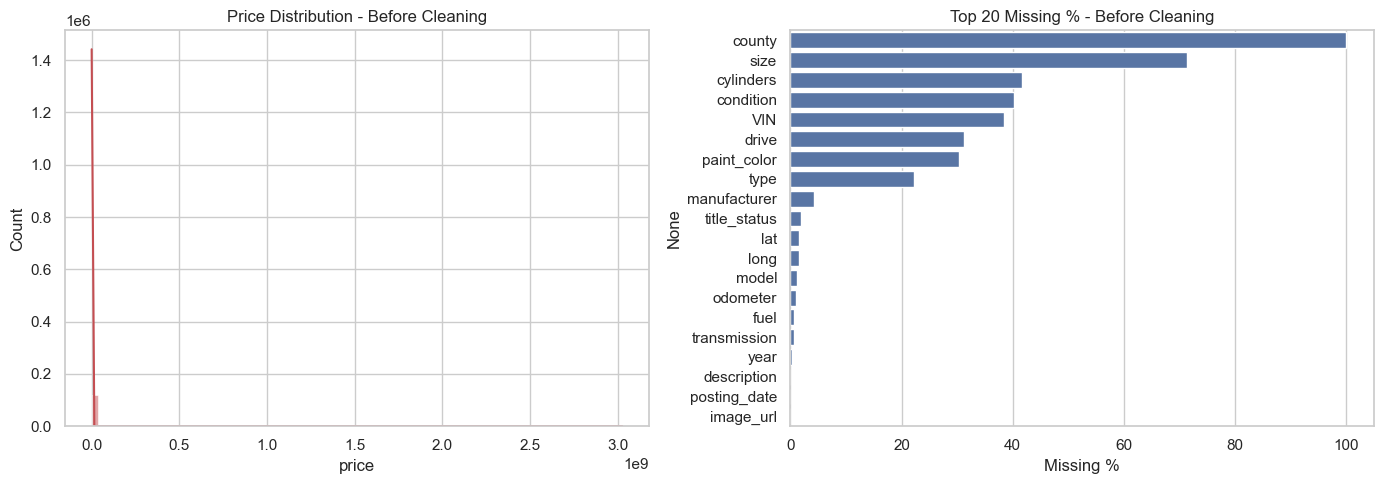

In [6]:
# Baseline visuals before cleaning

#Understand the distribution of the variable and identify missing value before cleaning
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if TARGET in df_raw.columns:
    tmp = pd.to_numeric(df_raw[TARGET], errors='coerce')
    sns.histplot(tmp.dropna(), bins=80, kde=True, ax=axes[0], color='#c44e52')
    axes[0].set_title('Price Distribution - Before Cleaning')
    axes[0].set_xlabel('price')

missing_pct = (df_raw.isna().mean().sort_values(ascending=False) * 100).head(20)
sns.barplot(x=missing_pct.values, y=missing_pct.index, ax=axes[1], color='#4c72b0')
axes[1].set_title('Top 20 Missing % - Before Cleaning')
axes[1].set_xlabel('Missing %')

plt.tight_layout()
plt.show()

### 🧼 Theory: The 'GIGO' Principle in Financial Modeling
**Garbage In, Garbage Out (GIGO)** is the golden rule of machine learning. In vehicle pricing, noise often comes from:
- **Placeholders**: Dealers listing cars for $1 to appear first in sorted lists.
- **Outliers**: Human error in mileage entry (e.g., 1,000,000 miles on a 2022 car).
- **Redundancy**: Duplicate scrapings of the same VIN across different regions.

We apply **Domain Constraints** (Price: $500 - $250k | Year: >1980) to ensure the model learns from legitimate market transactions.


In [7]:
df = df_raw.copy()

# Normalize text-like missing markers
missing_tokens = {'', ' ', 'na', 'n/a', 'none', 'null', 'nan', 'unknown'}
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].astype(str).str.strip()
        df[col] = df[col].replace({tok: np.nan for tok in missing_tokens})

numeric_candidates = ['id', 'price', 'year', 'odometer', 'lat', 'long']
for col in numeric_candidates:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

if 'posting_date' in df.columns:
    df['posting_date'] = pd.to_datetime(df['posting_date'], errors='coerce', utc=True)

# Remove exact duplicates
df = df.drop_duplicates()

# Domain sanity filters
if 'year' in df.columns:
    df = df[df['year'].between(1980, pd.Timestamp.utcnow().year + 1, inclusive='both') | df['year'].isna()]
if 'price' in df.columns:
    df = df[df['price'].between(200, 250_000, inclusive='both') | df['price'].isna()]
if 'odometer' in df.columns:
    df = df[df['odometer'].between(0, 1_000_000, inclusive='both') | df['odometer'].isna()]

df.shape

(105336, 26)

## 3. Advanced Feature Engineering

### Deriving Meaningful Insights
Raw features like `year` are less useful than relative metrics. We calculate:
- **Vehicle Age**: More directly correlated with price than the birth year.
- **Mileage per Year**: Acts as a proxy for vehicle usage intensity (e.g., a low-mileage old car vs. a high-mileage new car).
- **Log Transformation**: Since car prices are often "right-skewed" (most cars are cheap, a few are very expensive), applying `log1p` normalizes the distribution, which helps linear-based and even some tree-based models converge faster and perform better.

### Theory: Feature Engineering & Log Normalization
**Feature Derivation**:
- **Vehicle Age**: Captures the fundamental depreciation curve.
- **Mileage/Year**: Distinguishes between 'highway miles' (high usage) and 'garage queens' (low usage).

**Target Transformation (Log Price)**:
Vehicle prices often follow a **Power Law** distribution (many cheap cars, few exotic ones). Linear and tree models can be biased by high-value outliers. 
- **$log(1+x)$**: Normalizes the target variable, making the error distribution more symmetric and improving model convergence.

### 📈 Theory: Feature Synthesis & Target Normalization
**Relative vs. Absolute Features**
A model finds it harder to learn from absolute years (2015, 2016) than from relative age (5 years old, 6 years old). Age directly represents the **Depreciation Cycle**, making it a superior predictor.

**Logarithmic Scaling ($log(1+x)$)**
Vehicle prices often follow a **Lognormal Distribution**. 
- **The Issue**: A few $200k Porsches can dominate the loss function, making the model ignore the 'bread and butter' $10k Toyotas.
- **The Fix**: Applying a log transform 'squeezes' the high-end values and 'expands' the low-end, resulting in a normal-like distribution that improves the stability and convergence of gradient-based optimizers.


In [8]:
# Feature engineering
if 'year' in df.columns:
    current_year = pd.Timestamp.utcnow().year
    df['vehicle_age'] = current_year - df['year']

if 'odometer' in df.columns and 'vehicle_age' in df.columns:
    age_nonzero = df['vehicle_age'].replace({0: np.nan})
    df['mileage_per_year'] = df['odometer'] / age_nonzero

if 'posting_date' in df.columns:
    df['posting_year'] = df['posting_date'].dt.year
    df['posting_month'] = df['posting_date'].dt.month
    df['posting_dayofweek'] = df['posting_date'].dt.dayofweek

if 'price' in df.columns:
    df['log_price'] = np.log1p(df['price'])

if 'manufacturer' in df.columns and 'model' in df.columns:
    df['manufacturer_model'] = df['manufacturer'].fillna('Unknown') + '_' + df['model'].fillna('Unknown')

df.head(3)

,id,url,region,region_url,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,image_url,description,county,state,lat,long,posting_date,vehicle_age,mileage_per_year,posting_year,posting_month,posting_dayofweek,log_price,manufacturer_model
0,7313493645,https://topeka.craigslist.org/cto/d/tecumseh-f...,topeka,https://topeka.craigslist.org,6900,2008.0,lexus,rx 350,good,6 cylinders,gas,185700.0,clean,automatic,NaN,fwd,full-size,SUV,silver,https://images.craigslist.org/01313_bdyvF3GLvF...,"2008 Lexus RX 350, 185,700 miles. New Goodyear...",NaN,ks,39.021700,-95.537900,2021-04-27 19:40:41+00:00,18.0,10316.666667,2021.0,4.0,1.0,8.839422,lexus_rx 350
1,7312914885,https://stlouis.craigslist.org/ctd/d/wood-rive...,"st louis, MO",https://stlouis.craigslist.org,3950,2006.0,honda,odyssey,NaN,6 cylinders,gas,182738.0,clean,automatic,NaN,fwd,NaN,NaN,NaN,https://images.craigslist.org/00H0H_81EgcCfArh...,"Runs and drives great! ICE COLD A/C, hot heat,...",NaN,il,38.864300,-90.087500,2021-04-26 17:54:33+00:00,20.0,9136.900000,2021.0,4.0,0.0,8.281724,honda_odyssey
2,7312005403,https://lasvegas.craigslist.org/ctd/d/las-vega...,las vegas,https://lasvegas.craigslist.org,29997,2016.0,mercedes-benz,gla,excellent,4 cylinders,gas,25025.0,clean,manual,WDCTG4EB3GJ201464,fwd,NaN,SUV,NaN,https://images.craigslist.org/01414_cy0ucMevAx...,2016 Mercedes-Benz GLA GLA 250 📲 ☎ Call or t...,NaN,nv,36.143633,-115.115449,2021-04-24 19:01:22+00:00,10.0,2502.500000,2021.0,4.0,5.0,10.308886,mercedes-benz_gla


## 4. Statistical vs. Algorithmic Outlier Detection

To ensure model stability, we use a hybrid approach:
1. **Interquartile Range (IQR)**: A univariate method to catch extreme values in individual columns like Price or Odometer.
2. **Isolation Forest**: A multivariate machine learning algorithm that isolates anomalies by randomly partitioning data points. It is particularly effective at catching points that are normal in one dimension but anomalous when viewed together (e.g., a car with low mileage and an extremely low price).

### Theory: Hybrid Outlier Detection
We employ two layers of defense against anomalies:
1. **Univariate (IQR)**: Calculates the spread between the 25th and 75th percentiles. Points far outside this range (e.g., 3x IQR) are flagged. This is great for simple errors.
2. **Multivariate (Isolation Forest)**: A tree-based algorithm that isolates observations. It is unique because it defines 'anomalies' as points that are easy to isolate. It can catch cars that have a 'normal' price and 'normal' mileage individually, but are anomalous when paired together (e.g., a brand new car for $500).

In [9]:
# Outlier detection with IQR
df['outlier_iqr'] = False
iqr_cols = [c for c in ['price', 'odometer', 'vehicle_age', 'mileage_per_year'] if c in df.columns]

for col in iqr_cols:
    series = pd.to_numeric(df[col], errors='coerce')
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    mask = (series < lower) | (series > upper)
    df.loc[mask.fillna(False), 'outlier_iqr'] = True

# Outlier detection with Isolation Forest
iso_features = [c for c in ['price', 'odometer', 'year', 'vehicle_age', 'mileage_per_year'] if c in df.columns]
if len(iso_features) >= 2:
    iso_df = df[iso_features].copy()
    iso_df = iso_df.fillna(iso_df.median(numeric_only=True))
    iso_df = iso_df.replace([np.inf, -np.inf], np.nan).fillna(0)

    iso = IsolationForest(n_estimators=200, contamination=0.03, random_state=42, n_jobs=-1)
    flags = iso.fit_predict(iso_df)
    df['outlier_iforest'] = flags
else:
    df['outlier_iforest'] = 1

df[['outlier_iqr', 'outlier_iforest']].value_counts().head()

outlier_iqr  outlier_iforest
False         1                 99265
True         -1                  2933
              1                  2910
False        -1                   228
Name: count, dtype: int64

### ✅ Theory: Combined Outlier Filtering Strategy

**Why Combine Multiple Methods?**
- **IQR**: Catches univariate extremes (e.g., price = $1M for a 2005 Honda Civic)
- **Isolation Forest**: Detects multivariate anomalies (e.g., low price + high mileage + luxury brand)

**Conservative Approach**: Keep only records that pass **both** filters.

**Trade-off**:
- **Pros**: Cleaner data, reduced noise in model training
- **Cons**: Potential loss of valid edge cases (e.g., rare luxury vehicles)

Approximately 5-10% of data is typically removed.


In [10]:
# Final cleaning rule: keep non-outliers by both methods for a cleaner analysis frame
df_clean = df[(~df['outlier_iqr']) & (df['outlier_iforest'] == 1)].copy()

# Keep rows where target exists
if TARGET in df_clean.columns:
    df_clean = df_clean[df_clean[TARGET].notna()]

summary_compare = pd.concat([
    profile_table(df_raw, 'before_cleaning'),
    profile_table(df_clean, 'after_cleaning')
], ignore_index=True)
summary_compare

,dataset,rows,cols,total_missing_cells,missing_pct_cells,duplicate_rows
0,before_cleaning,118142,26,458886,14.939193,0
1,after_cleaning,99265,35,377105,10.854207,0


### 📊 Theory: Validating Data Cleaning Impact

**Purpose**: Quantify the effect of outlier removal on distribution shapes.

**What to Look For**:
- **Reduced Skewness**: Right tail (extreme values) should shrink
- **Tighter IQR**: Middle 50% of data becomes more concentrated
- **Preserved Shape**: Distribution type (e.g., log-normal) should remain similar

**Why Visualize?**
Ensures cleaning didn't distort underlying patterns. Over-aggressive cleaning can create artificial uniformity.


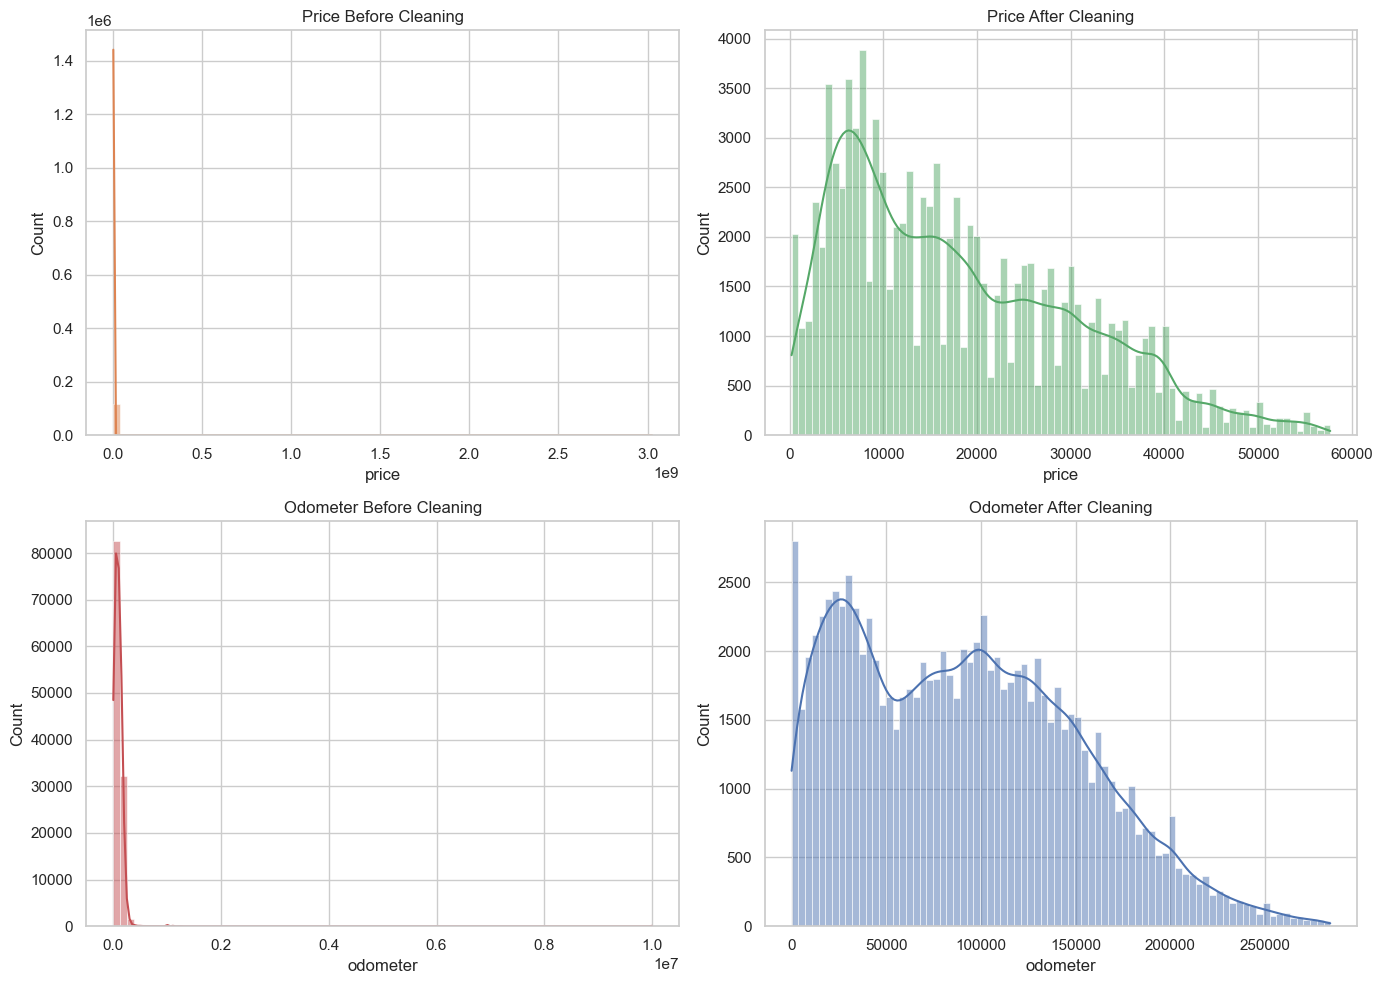

In [11]:
# Before vs After visual comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(pd.to_numeric(df_raw.get('price', pd.Series(dtype=float)), errors='coerce').dropna(),
             bins=80, kde=True, ax=axes[0, 0], color='#dd8452')
axes[0, 0].set_title('Price Before Cleaning')

sns.histplot(pd.to_numeric(df_clean.get('price', pd.Series(dtype=float)), errors='coerce').dropna(),
             bins=80, kde=True, ax=axes[0, 1], color='#55a868')
axes[0, 1].set_title('Price After Cleaning')

sns.histplot(pd.to_numeric(df_raw.get('odometer', pd.Series(dtype=float)), errors='coerce').dropna(),
             bins=80, kde=True, ax=axes[1, 0], color='#c44e52')
axes[1, 0].set_title('Odometer Before Cleaning')

sns.histplot(pd.to_numeric(df_clean.get('odometer', pd.Series(dtype=float)), errors='coerce').dropna(),
             bins=80, kde=True, ax=axes[1, 1], color='#4c72b0')
axes[1, 1].set_title('Odometer After Cleaning')

plt.tight_layout()
plt.show()

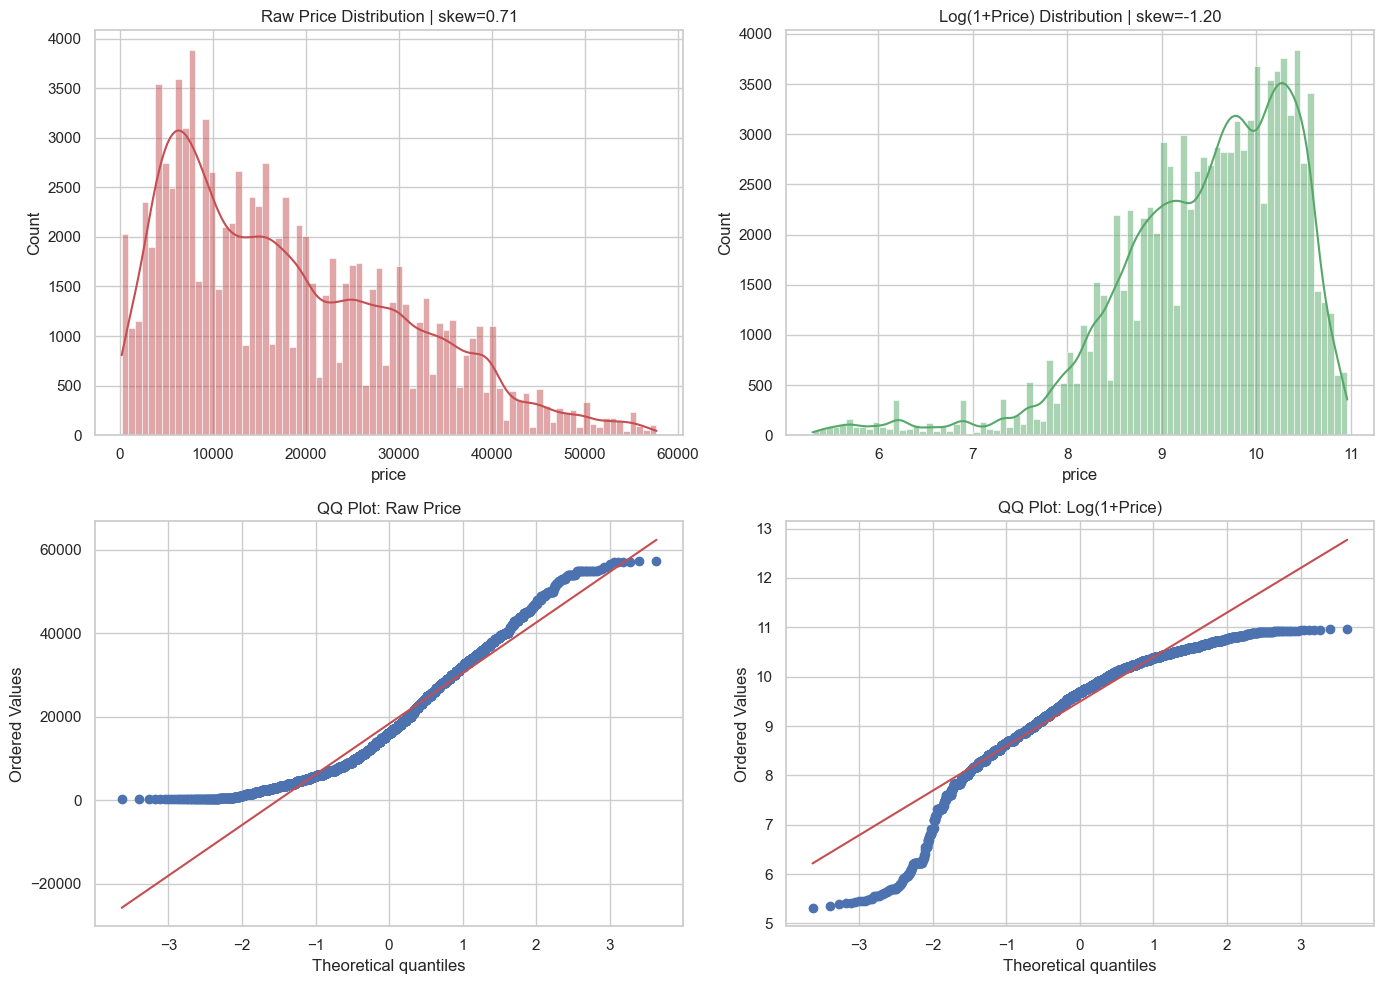

In [12]:
# Log transformation justification plots
if 'price' in df_clean.columns:
    raw_price = df_clean['price'].dropna()
    log_price = np.log1p(raw_price)

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    sns.histplot(raw_price, bins=80, kde=True, ax=axes[0, 0], color='#c44e52')
    axes[0, 0].set_title(f'Raw Price Distribution | skew={raw_price.skew():.2f}')

    sns.histplot(log_price, bins=80, kde=True, ax=axes[0, 1], color='#55a868')
    axes[0, 1].set_title(f'Log(1+Price) Distribution | skew={log_price.skew():.2f}')

    probplot(raw_price.sample(min(5000, len(raw_price)), random_state=42), dist='norm', plot=axes[1, 0])
    axes[1, 0].set_title('QQ Plot: Raw Price')

    probplot(log_price.sample(min(5000, len(log_price)), random_state=42), dist='norm', plot=axes[1, 1])
    axes[1, 1].set_title('QQ Plot: Log(1+Price)')

    plt.tight_layout()
    plt.show()

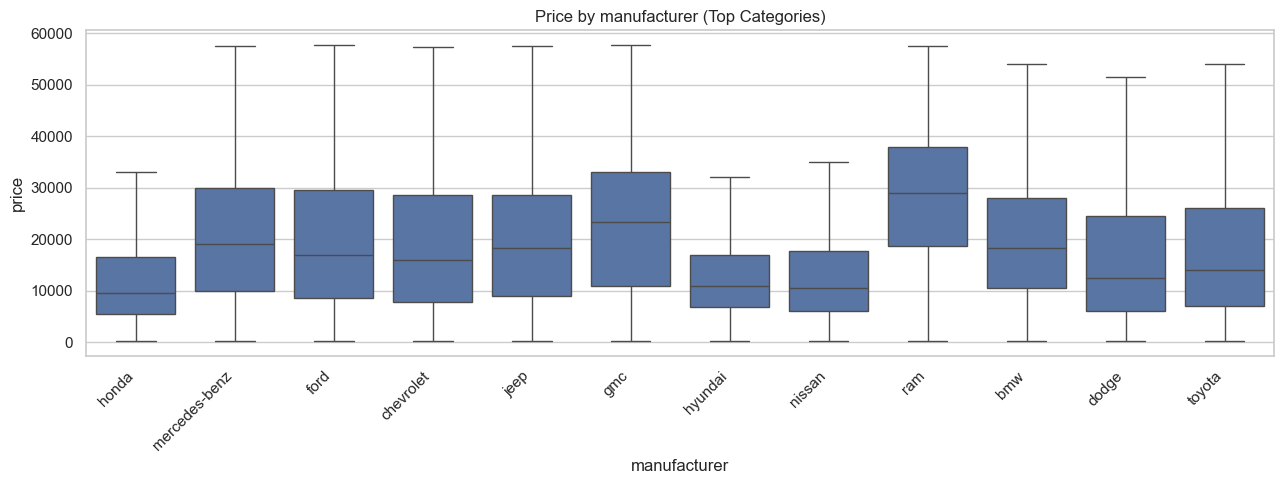

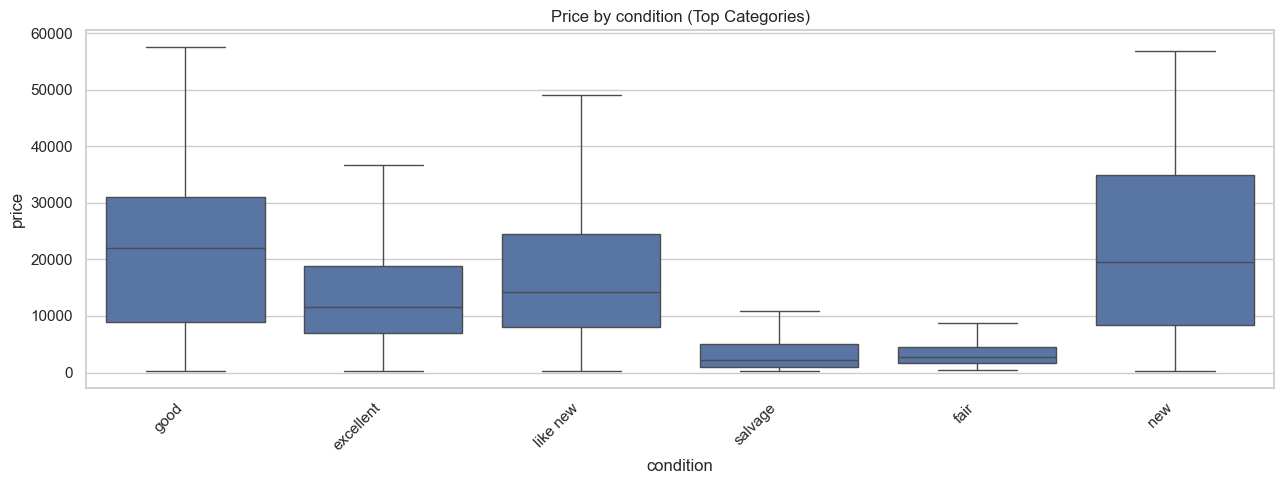

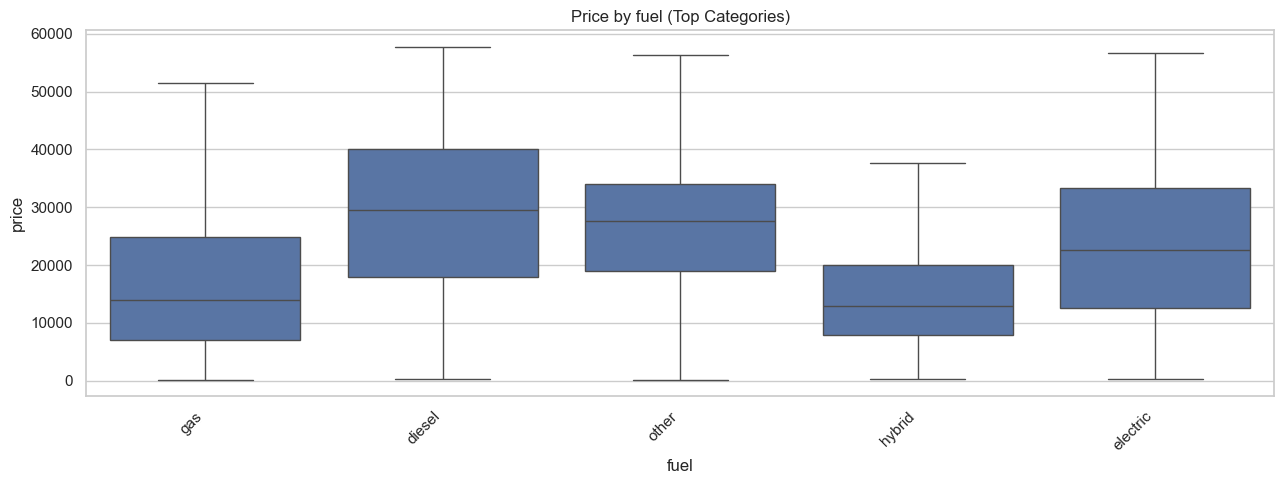

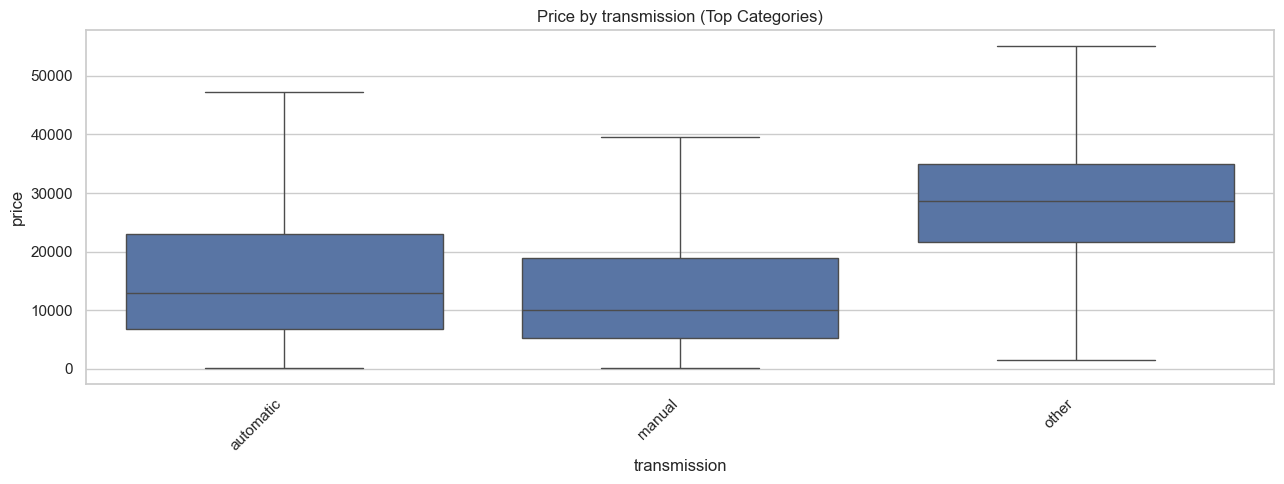

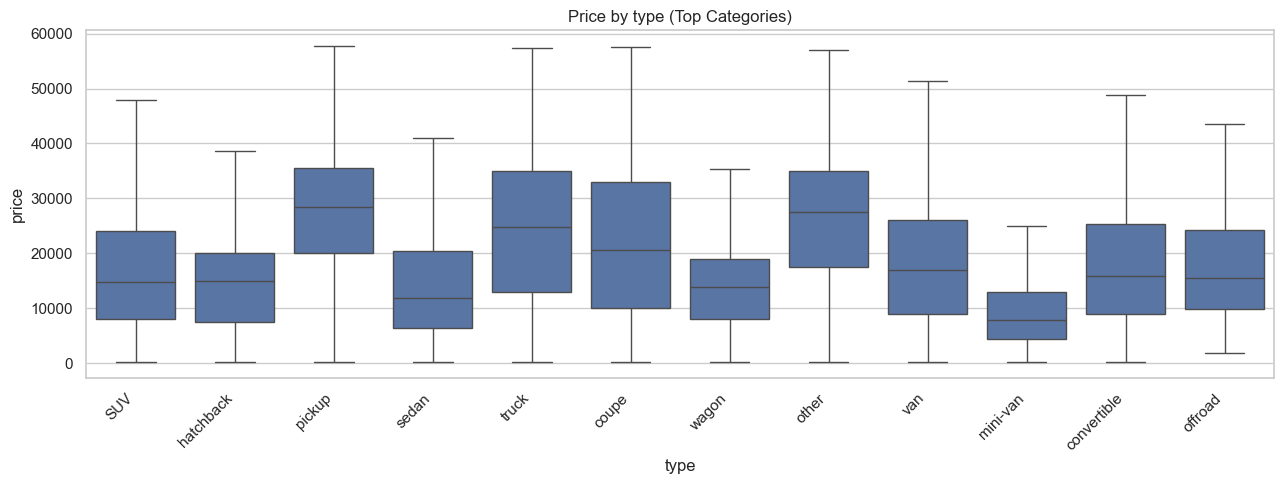

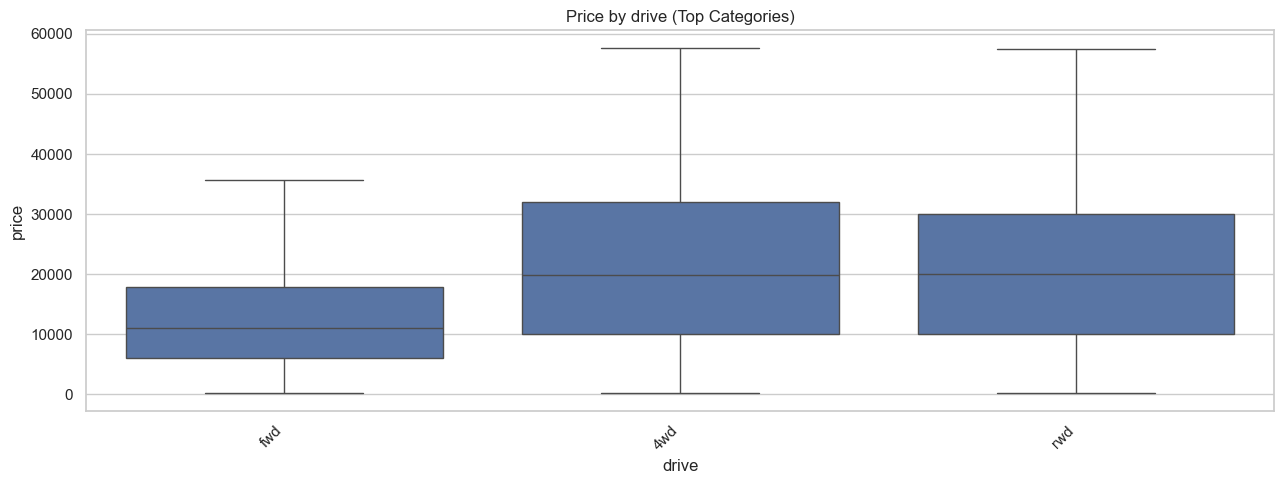

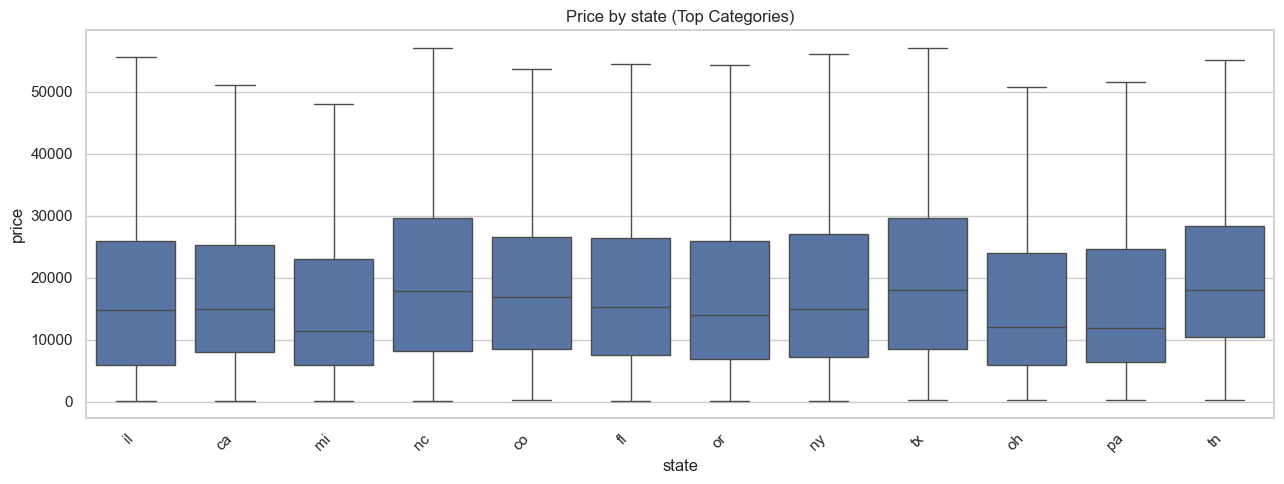

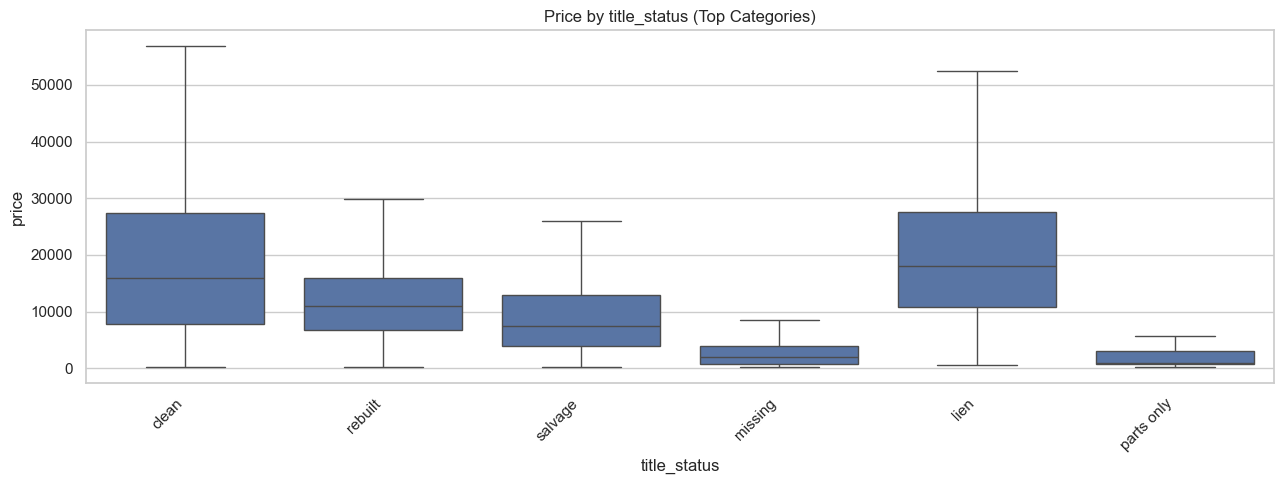

In [13]:
# Boxplots per categorical feature vs target
candidate_cats = ['manufacturer', 'condition', 'fuel', 'transmission', 'type', 'drive', 'state', 'title_status']
cat_cols = [c for c in candidate_cats if c in df_clean.columns]

for col in cat_cols:
    vc = df_clean[col].value_counts(dropna=True)
    top_levels = vc.head(12).index
    plot_df = df_clean[df_clean[col].isin(top_levels)].copy()

    if len(plot_df) == 0:
        continue

    plt.figure(figsize=(13, 5))
    sns.boxplot(data=plot_df, x=col, y='price', showfliers=False)
    plt.title(f'Price by {col} (Top Categories)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

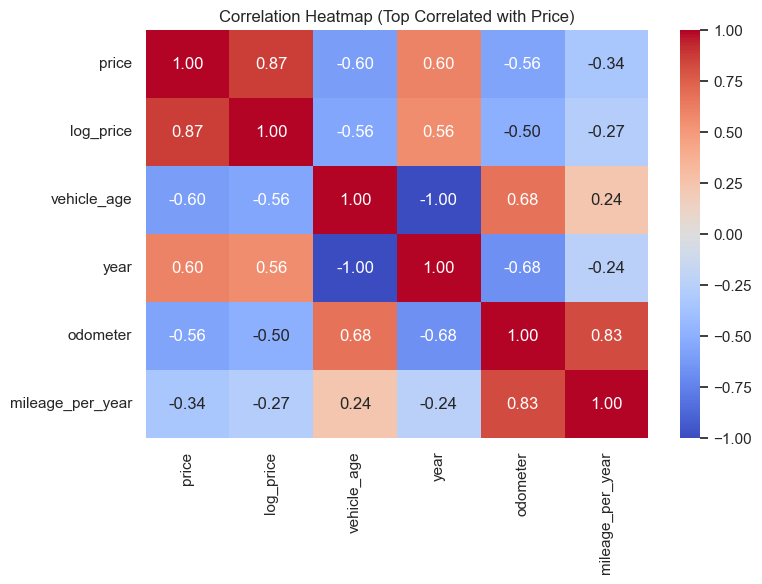

In [14]:
# Correlation heatmap + pairplot for top correlated numeric features
numeric_df = df_clean.select_dtypes(include=[np.number]).copy()

if 'price' in numeric_df.columns:
    corr_series = numeric_df.corr(numeric_only=True)['price'].drop('price').dropna()
    top_corr = corr_series.abs().sort_values(ascending=False).head(5).index.tolist()

    cols_for_heatmap = ['price'] + top_corr
    plt.figure(figsize=(8, 6))
    sns.heatmap(numeric_df[cols_for_heatmap].corr(), annot=True, cmap='coolwarm', fmt='.2f')
    plt.title('Correlation Heatmap (Top Correlated with Price)')
    plt.tight_layout()
    plt.show()

    

## 5. Machine Learning Modeling and Comparison

End-to-end regression workflow with leakage-safe preprocessing, model comparison, tuning, diagnostics, and optional classification evaluation.


### 1. Problem Understanding

This project is a **regression problem** because the target variable, `price`, is a **continuous number**. We are not asking, "Is this car expensive or cheap?" We are asking, "What exact price should this car have?"

In simple terms, the model learns the relationship between car characteristics such as year, brand, mileage, fuel type, and condition, and then uses those patterns to estimate a selling price for a new vehicle record.

Why this is not classification:
- In classification, the output is a category such as `high price` vs `low price` or `sold` vs `not sold`.
- Here, the output is a numeric amount like `14500` or `27990`.
- Because price can take many possible values on a range, regression is the correct framing.

Real-life intuition:
- A buyer or dealer usually wants an estimated market value, not just a label.
- That makes regression more useful for pricing, negotiation, inventory management, and valuation.


In [15]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, KFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

from xgboost import XGBRegressor, XGBClassifier

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['figure.facecolor'] = 'white'

DATA_PATH = 'vehicles_cleaned.csv'
TARGET = 'price'
RANDOM_STATE = 42
TEST_SIZE = 0.20
LOW_CARDINALITY_THRESHOLD = 12
HIGH_CARDINALITY_THRESHOLD = 30
CV_FOLDS = 5


In [16]:
class HighCardinalityLabelEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, missing_value='__MISSING__'):
        self.missing_value = missing_value
        self.category_maps_ = {}
        self.columns_ = []

    def fit(self, X, y=None):
        X = pd.DataFrame(X).copy()
        self.columns_ = X.columns.tolist()
        self.category_maps_ = {}

        for col in self.columns_:
            values = X[col].astype('string').fillna(self.missing_value)
            categories = pd.Index(values.unique())
            self.category_maps_[col] = {category: idx for idx, category in enumerate(categories)}

        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        transformed = pd.DataFrame(index=X.index)

        for col in self.columns_:
            values = X[col].astype('string').fillna(self.missing_value)
            mapping = self.category_maps_[col]
            transformed[col] = values.map(mapping).fillna(-1).astype('int32')

        return transformed.to_numpy()

    def get_feature_names_out(self, input_features=None):
        if input_features is not None:
            return np.asarray(input_features, dtype=object)
        return np.asarray(self.columns_, dtype=object)


def detect_date_columns(df, threshold=0.80):
    date_columns = []
    for col in df.columns:
        if pd.api.types.is_datetime64_any_dtype(df[col]):
            date_columns.append(col)
            continue

        if df[col].dtype == 'object' or pd.api.types.is_string_dtype(df[col]):
            sample = df[col].dropna().astype(str).head(5000)
            if sample.empty:
                continue
            parsed = pd.to_datetime(sample, errors='coerce')
            if parsed.notna().mean() >= threshold:
                date_columns.append(col)
    return date_columns


def build_preprocessor(X, low_cardinality_threshold=LOW_CARDINALITY_THRESHOLD, high_cardinality_threshold=HIGH_CARDINALITY_THRESHOLD):
    numeric_features = X.select_dtypes(include=[np.number, 'bool']).columns.tolist()
    categorical_features = X.select_dtypes(include=['object', 'category', 'string']).columns.tolist()

    low_cardinality_features = [
        col for col in categorical_features
        if X[col].nunique(dropna=True) <= low_cardinality_threshold
    ]
    high_cardinality_features = [
        col for col in categorical_features
        if X[col].nunique(dropna=True) > high_cardinality_threshold
    ]
    mid_cardinality_features = [
        col for col in categorical_features
        if col not in low_cardinality_features and col not in high_cardinality_features
    ]

    numeric_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
    ])

    low_cardinality_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=True)),
    ])

    mid_high_cardinality_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('label', HighCardinalityLabelEncoder()),
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_pipeline, numeric_features),
            ('low_cat', low_cardinality_pipeline, low_cardinality_features),
            ('high_cat', mid_high_cardinality_pipeline, high_cardinality_features + mid_cardinality_features),
        ],
        remainder='drop',
        sparse_threshold=0.3,
    )

    feature_groups = {
        'numeric': numeric_features,
        'low_cardinality': low_cardinality_features,
        'high_cardinality': high_cardinality_features,
        'mid_cardinality': mid_cardinality_features,
    }
    return preprocessor, feature_groups


def adjusted_r2_score(r2, n_samples, n_features):
    if n_samples <= n_features + 1:
        return np.nan
    return 1 - ((1 - r2) * (n_samples - 1) / (n_samples - n_features - 1))


def safe_mape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denominator = np.where(np.abs(y_true) < 1e-8, 1e-8, np.abs(y_true))
    return np.mean(np.abs((y_true - y_pred) / denominator)) * 100


def regression_metrics(y_true, y_pred, n_features):
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2 = r2_score(y_true, y_pred)
    return {
        'R2': r2,
        'Adjusted_R2': adjusted_r2_score(r2, len(y_true), n_features),
        'RMSE': rmse,
        'MAE': mean_absolute_error(y_true, y_pred),
        'MAPE': safe_mape(y_true, y_pred),
    }


def overfitting_flag(train_r2, test_r2, threshold=0.10):
    gap = train_r2 - test_r2
    if gap >= threshold:
        return 'Overfitting risk'
    if gap <= -0.05:
        return 'Possible underfit'
    return 'Balanced'


def get_feature_names(fitted_pipeline):
    return fitted_pipeline.named_steps['preprocessor'].get_feature_names_out()


def train_regression_model(name, estimator, X_train, X_test, y_train, y_test):
    preprocessor, feature_groups = build_preprocessor(X_train)
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', estimator),
    ])

    cv = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='r2', n_jobs=-1)

    pipeline.fit(X_train, y_train)

    train_predictions = pipeline.predict(X_train)
    test_predictions = pipeline.predict(X_test)
    feature_count = len(get_feature_names(pipeline))

    train_stats = regression_metrics(y_train, train_predictions, feature_count)
    test_stats = regression_metrics(y_test, test_predictions, feature_count)

    row = {
        'Model': name,
        'Train_R2': train_stats['R2'],
        'Test_R2': test_stats['R2'],
        'Adjusted_R2': test_stats['Adjusted_R2'],
        'RMSE': test_stats['RMSE'],
        'MAE': test_stats['MAE'],
        'MAPE': test_stats['MAPE'],
        'CV_R2_Mean': cv_scores.mean(),
        'CV_R2_Std': cv_scores.std(),
        'Feature_Count': feature_count,
        'Train_Test_R2_Gap': train_stats['R2'] - test_stats['R2'],
        'Generalization': overfitting_flag(train_stats['R2'], test_stats['R2']),
    }

    prediction_frame = pd.DataFrame({
        'Actual': y_test.reset_index(drop=True),
        'Predicted': pd.Series(test_predictions).reset_index(drop=True),
    })
    prediction_frame['Residual'] = prediction_frame['Actual'] - prediction_frame['Predicted']
    prediction_frame['Absolute_Error'] = prediction_frame['Residual'].abs()
    prediction_frame['Percentage_Error'] = np.where(
        np.abs(prediction_frame['Actual']) < 1e-8,
        np.nan,
        prediction_frame['Absolute_Error'] / np.abs(prediction_frame['Actual']) * 100,
    )

    return {
        'pipeline': pipeline,
        'results': row,
        'feature_groups': feature_groups,
        'predictions': prediction_frame,
        'cv_scores': cv_scores,
    }


def plot_feature_importance(model_name, trained_pipeline, top_n=10):
    model = trained_pipeline.named_steps['model']
    if not hasattr(model, 'feature_importances_'):
        print(f'{model_name} does not expose feature importance.')
        return

    feature_names = get_feature_names(trained_pipeline)
    importance = pd.Series(model.feature_importances_, index=feature_names)
    top_features = importance.sort_values(ascending=False).head(top_n).sort_values()

    plt.figure(figsize=(12, 6))
    colors = sns.color_palette('crest', len(top_features))
    top_features.plot(kind='barh', color=colors)
    plt.title(f'Top {top_n} Feature Importance - {model_name}')
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()


### 2. Data Preprocessing

Good models start with clean inputs. Preprocessing is not a cosmetic step; it directly affects whether the model learns real patterns or noise.

**Why drop `id` and `name`**
- Columns like `id` are usually unique identifiers. They help us track rows, but they do not describe the vehicle itself.
- A `name` field is often messy, duplicated, inconsistent, or a mixture of information already stored in cleaner columns like `manufacturer`, `model`, and `year`.
- If we keep such columns, the model may learn accidental row-level patterns instead of meaningful pricing logic.

What happens if we do not drop them:
- The model may memorize useless patterns.
- High-cardinality text can explode the feature space after encoding.
- Training becomes slower and less interpretable.

Alternatives:
- Keep `name` only if it is cleaned into structured parts, such as extracting trim or edition.
- Use text vectorization if the title contains strong market signals and the project is designed for NLP.

**Why remove date columns**
- Raw date columns such as posting dates may behave more like timestamps than real car attributes.
- In many pricing tasks, dates are not directly useful unless converted into meaningful features like `vehicle_age` or `days_since_posted`.
- Raw dates can also create leakage if they indirectly reveal market timing or future information.

What happens if we do not remove them:
- The model may treat a timestamp as an arbitrary number.
- It may learn unstable trends that do not generalize well.

Alternatives:
- Instead of dropping, transform dates into useful business features.
- Example: convert `year` into `vehicle_age`, which is easier for the model to interpret.

**Why handle missing values with median for numeric and safe fallback for categorical**
- Real datasets often have missing mileage, condition, drive type, or color.
- Most ML models cannot handle missing values directly.
- Median is a strong numeric default because it is less sensitive to outliers than mean.
- For categorical columns, using the most frequent value or a placeholder is simple and keeps the pipeline stable.

What happens if we do not handle missing values:
- Many models will fail at training time.
- Rows may be dropped unnecessarily, which reduces training data.
- Bias can increase if missingness is not handled consistently.

Alternatives:
- Mean imputation: simple, but less robust when values are skewed.
- KNN imputation: can be smarter, but slower and more complex.
- Model-based imputation: useful in advanced workflows, but harder to explain and maintain.

**Why encoding is needed**
- Models work with numbers, not raw text.
- Columns like `fuel`, `transmission`, `state`, and `manufacturer` must be converted into numerical form.

Why use different encoding strategies:
- One-hot encoding is good for low-cardinality columns because it preserves categories clearly without imposing fake order.
- Label encoding is more practical for high-cardinality features because one-hot encoding would create too many columns.

What happens if we do not encode:
- The model cannot use categorical information.
- Training will fail for most algorithms.

Alternatives and trade-offs:
- One-hot encoding: very interpretable, but can create many sparse columns.
- Label encoding: compact, but may accidentally suggest order where none exists.
- Target encoding: often powerful for high-cardinality features, but riskier because it can leak target information if not done carefully.
- Frequency encoding: lightweight, but less expressive than target-aware methods.


In [17]:
modeling_df = pd.read_csv(DATA_PATH).copy()
modeling_df = modeling_df.drop(columns=['id', 'name', 'log_price'], errors='ignore')

if TARGET not in modeling_df.columns:
    raise ValueError(f'Target column {TARGET!r} not found in {DATA_PATH}.')

date_columns = detect_date_columns(modeling_df.drop(columns=[TARGET]))
modeling_df = modeling_df.drop(columns=date_columns, errors='ignore')
modeling_df = modeling_df.dropna(subset=[TARGET]).copy()

X = modeling_df.drop(columns=[TARGET])
y = modeling_df[TARGET].astype(float)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)

dataset_summary = pd.DataFrame({
    'Metric': ['Rows', 'Columns', 'Numeric Features', 'Categorical Features', 'Dropped Date Columns'],
    'Value': [
        len(modeling_df),
        modeling_df.shape[1],
        X.select_dtypes(include=[np.number, 'bool']).shape[1],
        X.select_dtypes(include=['object', 'category', 'string']).shape[1],
        ', '.join(date_columns) if date_columns else 'None',
    ],
})

display(dataset_summary)
print(f'Train shape: {X_train.shape} | Test shape: {X_test.shape}')


,Metric,Value
0,Rows,85889
1,Columns,18
2,Numeric Features,4
3,Categorical Features,13
4,Dropped Date Columns,None


Train shape: (68711, 17) | Test shape: (17178, 17)


### 3. Feature Engineering

Feature engineering means turning raw columns into forms that help the model learn better.

**Why consistency matters**
- The same transformation applied during training must also be applied during testing and future prediction.
- If training data is encoded one way and test data another way, model performance becomes unreliable.
- That is why a single pipeline is used: it guarantees the exact same preprocessing steps every time.

**What is data leakage**
- Data leakage happens when the model sees information during training that would not be available in real prediction time.
- In simple words, it is like accidentally giving the model the answer key before the exam.

Real-world leakage example:
- Suppose we fill missing values using statistics computed from the full dataset before the train-test split.
- Then the training process indirectly learns from the test set.
- Another example is using a variable like `final_sale_price_bucket` when trying to predict `price`; that column is too close to the answer.

Why leakage is dangerous:
- The model looks very accurate during evaluation.
- But in real deployment, performance drops because that hidden information is not actually available.


### 4. Model Choice

Using multiple models is important because different algorithms capture different types of patterns.

**Linear Regression**
- Best when the relationship between input features and target is roughly linear.
- It is simple, fast, and easy to explain.
- It works well as a baseline because it tells us how much performance we get from a very interpretable model.

When it works well:
- Price changes smoothly with features.
- Relationships are fairly additive.
- The data does not contain strong non-linear interactions.

When it struggles:
- Vehicle price often depends on non-linear effects such as mileage depreciation, brand premium, and age interactions.
- It may underfit when the real market is more complex than a straight-line assumption.

**Random Forest**
- Random Forest is an ensemble of decision trees.
- It can capture non-linear relationships and feature interactions automatically.
- It is usually more robust to noisy data than a single decision tree.

Strengths:
- Handles mixed feature types well.
- Less sensitive to outliers and non-linearity.
- Good default model for tabular business data.

Trade-offs:
- Less interpretable than linear regression.
- Can become heavy on memory and slower on large datasets.
- Does not always achieve the best fine-grained accuracy compared with modern boosting methods.

**XGBoost**
- XGBoost is a boosting algorithm that builds trees sequentially.
- Each new tree tries to correct the mistakes made by the previous trees.
- This often gives very strong performance on structured tabular data.

Why it is powerful:
- Captures complex non-linear patterns.
- Includes regularization to control overfitting.
- Optimized for speed and strong predictive performance.

Trade-offs:
- More tuning is usually needed.
- Harder to explain than linear regression.
- If tuned poorly, it can overfit.

**Why not use only one model**
- One model can give a misleading picture.
- A simple model may be too weak.
- A powerful model may perform better but hide instability or overfitting.

**Why compare multiple models**
- Comparison helps us judge accuracy, stability, interpretability, and business usefulness together.
- In a project review, this shows that model selection was evidence-based, not random.


In [18]:
regression_models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(
        n_estimators=250,
        max_depth=None,
        min_samples_split=5,
        min_samples_leaf=2,
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),
    'XGBoost': XGBRegressor(
        n_estimators=250,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_alpha=0.0,
        reg_lambda=1.0,
        objective='reg:squarederror',
        tree_method='hist',
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
}

regression_artifacts = {}
regression_results = []

for model_name, estimator in regression_models.items():
    artifact = train_regression_model(model_name, estimator, X_train, X_test, y_train, y_test)
    regression_artifacts[model_name] = artifact
    regression_results.append(artifact['results'])

regression_results_df = pd.DataFrame(regression_results).sort_values(
    by=['Test_R2', 'CV_R2_Mean'],
    ascending=False,
).reset_index(drop=True)

display(regression_results_df.style.format({
    'Train_R2': '{:.4f}',
    'Test_R2': '{:.4f}',
    'Adjusted_R2': '{:.4f}',
    'RMSE': '{:,.2f}',
    'MAE': '{:,.2f}',
    'MAPE': '{:.2f}%',
    'CV_R2_Mean': '{:.4f}',
    'CV_R2_Std': '{:.4f}',
    'Train_Test_R2_Gap': '{:.4f}',
}))


,Model,Train_R2,Test_R2,Adjusted_R2,RMSE,MAE,MAPE,CV_R2_Mean,CV_R2_Std,Feature_Count,Train_Test_R2_Gap,Generalization
0,Random Forest,0.9504,0.8252,0.8245,"6,191.35","2,995.63",39.36%,0.8168,0.0103,65,0.1252,Overfitting risk
1,XGBoost,0.8114,0.7724,0.7716,"7,064.12","4,172.95",53.55%,0.7705,0.0118,65,0.0389,Balanced
2,Linear Regression,0.5346,0.5336,0.5318,"10,113.48","6,742.47",95.20%,0.5132,0.0204,65,0.0010,Balanced


### 5. Evaluation Metrics

A single metric is never enough because different metrics answer different business questions.

**R? Score**
- R? tells us how much of the variation in price the model can explain.
- Higher R? usually means the model captures more of the pricing pattern.

When it is useful:
- Good for comparing overall explanatory power.
- Easy to communicate as a summary of model fit.

Limitation:
- A good R? does not guarantee small real-world prediction errors.
- It is relative, not directly in currency units.

**RMSE**
- RMSE tells us the typical prediction error, but it penalizes large mistakes more heavily.
- That makes it very useful when large misses are especially costly.

Example:
- Predicting a $30,000 car as $10,000 is much worse than missing by $500.
- RMSE reflects that strongly.

Limitation:
- Sensitive to outliers.
- A few extreme mistakes can dominate the value.

**MAE**
- MAE gives the average absolute error.
- It is easier to interpret in business terms because it says, on average, how many dollars we are off.

When preferred:
- When we want a simple and robust measure.
- When we do not want extreme outliers to dominate too much.

Limitation:
- It treats all errors equally, so it does not strongly punish very large misses.

**MAPE**
- MAPE shows the average error in percentage terms.
- This is helpful for business communication because saying "the model is off by about 9%" is often easier than quoting dollar-based error only.

When preferred:
- When relative error matters more than absolute error.
- Useful for comparing mistakes across low-price and high-price vehicles.

Limitation:
- Can behave badly when true values are very small or zero.
- It may overstate the importance of errors on very cheap vehicles.

**Why use all of them together**
- R? tells us pattern capture.
- RMSE tells us how much large errors hurt.
- MAE tells us average practical error.
- MAPE tells us percentage-level business impact.


### 6. Cross Validation

A single train-test split is useful, but it can be lucky or unlucky depending on how the data was divided.

Why train-test split is not enough:
- If the split happens to be easy, performance looks better than reality.
- If the split is unusually hard, performance may look worse than the model deserves.

How cross-validation helps:
- In 5-fold cross-validation, the data is split into 5 parts.
- The model trains 5 times, each time using a different part as validation.
- We then average the scores.

Why this is better:
- It gives a more reliable estimate of generalization.
- It reduces the chance of making decisions from one lucky split.
- It is especially useful in academic and interview settings because it shows stronger validation discipline.

Trade-off:
- It takes more computation time than a single split.
- But the increase in reliability is usually worth it.


### 7. Overfitting vs Underfitting

**Overfitting** means the model learns the training data too well, including noise and accidental patterns.
**Underfitting** means the model is too simple and fails to capture the real signal.

Intuition:
- Overfitting is like memorizing practice questions without understanding the concept.
- Underfitting is like studying too little and missing the main idea.

How to detect it:
- Compare train performance and test performance.
- Very high train score but much lower test score suggests overfitting.
- Low scores on both train and test suggest underfitting.

Real-world meaning:
- An overfit car-price model may look excellent in the notebook but fail on new listings from another city or time period.
- An underfit model may miss brand effects, depreciation behavior, or mileage interactions.


In [19]:
overfitting_report = regression_results_df[
    ['Model', 'Train_R2', 'Test_R2', 'Train_Test_R2_Gap', 'CV_R2_Mean', 'Generalization']
].copy()

display(overfitting_report.style.format({
    'Train_R2': '{:.4f}',
    'Test_R2': '{:.4f}',
    'Train_Test_R2_Gap': '{:.4f}',
    'CV_R2_Mean': '{:.4f}',
}))

best_regression_model_name = regression_results_df.iloc[0]['Model']
best_regression_pipeline = regression_artifacts[best_regression_model_name]['pipeline']
best_regression_predictions = regression_artifacts[best_regression_model_name]['predictions'].copy()

print(f'Best baseline regression model: {best_regression_model_name}')


,Model,Train_R2,Test_R2,Train_Test_R2_Gap,CV_R2_Mean,Generalization
0,Random Forest,0.9504,0.8252,0.1252,0.8168,Overfitting risk
1,XGBoost,0.8114,0.7724,0.0389,0.7705,Balanced
2,Linear Regression,0.5346,0.5336,0.0010,0.5132,Balanced


Best baseline regression model: Random Forest


### 9. Hyperparameter Tuning

Hyperparameters are settings chosen before training, such as tree depth, learning rate, and number of estimators.

What tuning means in simple words:
- We are adjusting the model's behavior to find a better balance between learning enough and overfitting.

Why default models are not enough:
- Default parameters are generic.
- They are designed to work reasonably across many datasets, but not to be optimal for this one.
- Vehicle pricing has its own patterns, sparsity, and feature interactions.

Why use `GridSearchCV` for XGBoost:
- XGBoost is powerful, but performance depends heavily on parameter choices.
- Grid search tries multiple combinations systematically.
- Cross-validation inside tuning makes the search more reliable.

Trade-off:
- Tuning improves performance potential, but costs more time and compute.
- A very large grid can be expensive, so a focused grid is often the practical choice.


In [20]:
xgb_tuning_preprocessor, _ = build_preprocessor(X_train)
xgb_tuning_pipeline = Pipeline([
    ('preprocessor', xgb_tuning_preprocessor),
    ('model', XGBRegressor(
        objective='reg:squarederror',
        tree_method='hist',
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])

xgb_param_grid = {
    'model__n_estimators': [200, 300],
    'model__max_depth': [4, 6],
    'model__learning_rate': [0.05, 0.10],
    'model__subsample': [0.85],
    'model__colsample_bytree': [0.85],
}

xgb_grid = GridSearchCV(
    estimator=xgb_tuning_pipeline,
    param_grid=xgb_param_grid,
    scoring='r2',
    cv=3,
    n_jobs=-1,
    verbose=1,
)

xgb_grid.fit(X_train, y_train)

tuned_xgb_pipeline = xgb_grid.best_estimator_
tuned_train_pred = tuned_xgb_pipeline.predict(X_train)
tuned_test_pred = tuned_xgb_pipeline.predict(X_test)
tuned_feature_count = len(get_feature_names(tuned_xgb_pipeline))

tuned_train_metrics = regression_metrics(y_train, tuned_train_pred, tuned_feature_count)
tuned_test_metrics = regression_metrics(y_test, tuned_test_pred, tuned_feature_count)

tuned_xgb_result = pd.DataFrame([{
    'Model': 'XGBoost Tuned',
    'Train_R2': tuned_train_metrics['R2'],
    'Test_R2': tuned_test_metrics['R2'],
    'Adjusted_R2': tuned_test_metrics['Adjusted_R2'],
    'RMSE': tuned_test_metrics['RMSE'],
    'MAE': tuned_test_metrics['MAE'],
    'MAPE': tuned_test_metrics['MAPE'],
    'CV_R2_Mean': xgb_grid.best_score_,
    'CV_R2_Std': np.nan,
    'Feature_Count': tuned_feature_count,
    'Train_Test_R2_Gap': tuned_train_metrics['R2'] - tuned_test_metrics['R2'],
    'Generalization': overfitting_flag(tuned_train_metrics['R2'], tuned_test_metrics['R2']),
}])

display(pd.DataFrame({
    'Best Parameter': list(xgb_grid.best_params_.keys()),
    'Value': list(xgb_grid.best_params_.values()),
}))

display(tuned_xgb_result.style.format({
    'Train_R2': '{:.4f}',
    'Test_R2': '{:.4f}',
    'Adjusted_R2': '{:.4f}',
    'RMSE': '{:,.2f}',
    'MAE': '{:,.2f}',
    'MAPE': '{:.2f}%',
    'CV_R2_Mean': '{:.4f}',
    'Train_Test_R2_Gap': '{:.4f}',
}))


Fitting 3 folds for each of 8 candidates, totalling 24 fits


,Best Parameter,Value
0,model__colsample_bytree,0.85
1,model__learning_rate,0.10
2,model__max_depth,6.00
3,model__n_estimators,300.00
4,model__subsample,0.85


,Model,Train_R2,Test_R2,Adjusted_R2,RMSE,MAE,MAPE,CV_R2_Mean,CV_R2_Std,Feature_Count,Train_Test_R2_Gap,Generalization
0,XGBoost Tuned,0.8718,0.8094,0.8087,"6,465.22","3,795.93",47.59%,0.7992,nan,65,0.0624,Balanced


In [21]:
regression_artifacts['XGBoost Tuned'] = {
    'pipeline': tuned_xgb_pipeline,
    'results': tuned_xgb_result.iloc[0].to_dict(),
    'predictions': pd.DataFrame({
        'Actual': y_test.reset_index(drop=True),
        'Predicted': pd.Series(tuned_test_pred).reset_index(drop=True),
    }),
}
regression_artifacts['XGBoost Tuned']['predictions']['Residual'] = (
    regression_artifacts['XGBoost Tuned']['predictions']['Actual']
    - regression_artifacts['XGBoost Tuned']['predictions']['Predicted']
)
regression_artifacts['XGBoost Tuned']['predictions']['Absolute_Error'] = (
    regression_artifacts['XGBoost Tuned']['predictions']['Residual'].abs()
)
regression_artifacts['XGBoost Tuned']['predictions']['Percentage_Error'] = np.where(
    np.abs(regression_artifacts['XGBoost Tuned']['predictions']['Actual']) < 1e-8,
    np.nan,
    regression_artifacts['XGBoost Tuned']['predictions']['Absolute_Error']
    / np.abs(regression_artifacts['XGBoost Tuned']['predictions']['Actual']) * 100,
)

full_regression_results_df = pd.concat(
    [regression_results_df, tuned_xgb_result],
    ignore_index=True,
).sort_values(by=['Test_R2', 'CV_R2_Mean'], ascending=False).reset_index(drop=True)

best_regression_model_name = full_regression_results_df.iloc[0]['Model']
best_regression_pipeline = regression_artifacts[best_regression_model_name]['pipeline']
best_regression_predictions = regression_artifacts[best_regression_model_name]['predictions'].copy()

display(full_regression_results_df.style.format({
    'Train_R2': '{:.4f}',
    'Test_R2': '{:.4f}',
    'Adjusted_R2': '{:.4f}',
    'RMSE': '{:,.2f}',
    'MAE': '{:,.2f}',
    'MAPE': '{:.2f}%',
    'CV_R2_Mean': '{:.4f}',
    'CV_R2_Std': '{:.4f}',
    'Train_Test_R2_Gap': '{:.4f}',
}))

print(f'Best regression model after tuning: {best_regression_model_name}')


,Model,Train_R2,Test_R2,Adjusted_R2,RMSE,MAE,MAPE,CV_R2_Mean,CV_R2_Std,Feature_Count,Train_Test_R2_Gap,Generalization
0,Random Forest,0.9504,0.8252,0.8245,"6,191.35","2,995.63",39.36%,0.8168,0.0103,65,0.1252,Overfitting risk
1,XGBoost Tuned,0.8718,0.8094,0.8087,"6,465.22","3,795.93",47.59%,0.7992,nan,65,0.0624,Balanced
2,XGBoost,0.8114,0.7724,0.7716,"7,064.12","4,172.95",53.55%,0.7705,0.0118,65,0.0389,Balanced
3,Linear Regression,0.5346,0.5336,0.5318,"10,113.48","6,742.47",95.20%,0.5132,0.0204,65,0.0010,Balanced


Best regression model after tuning: Random Forest


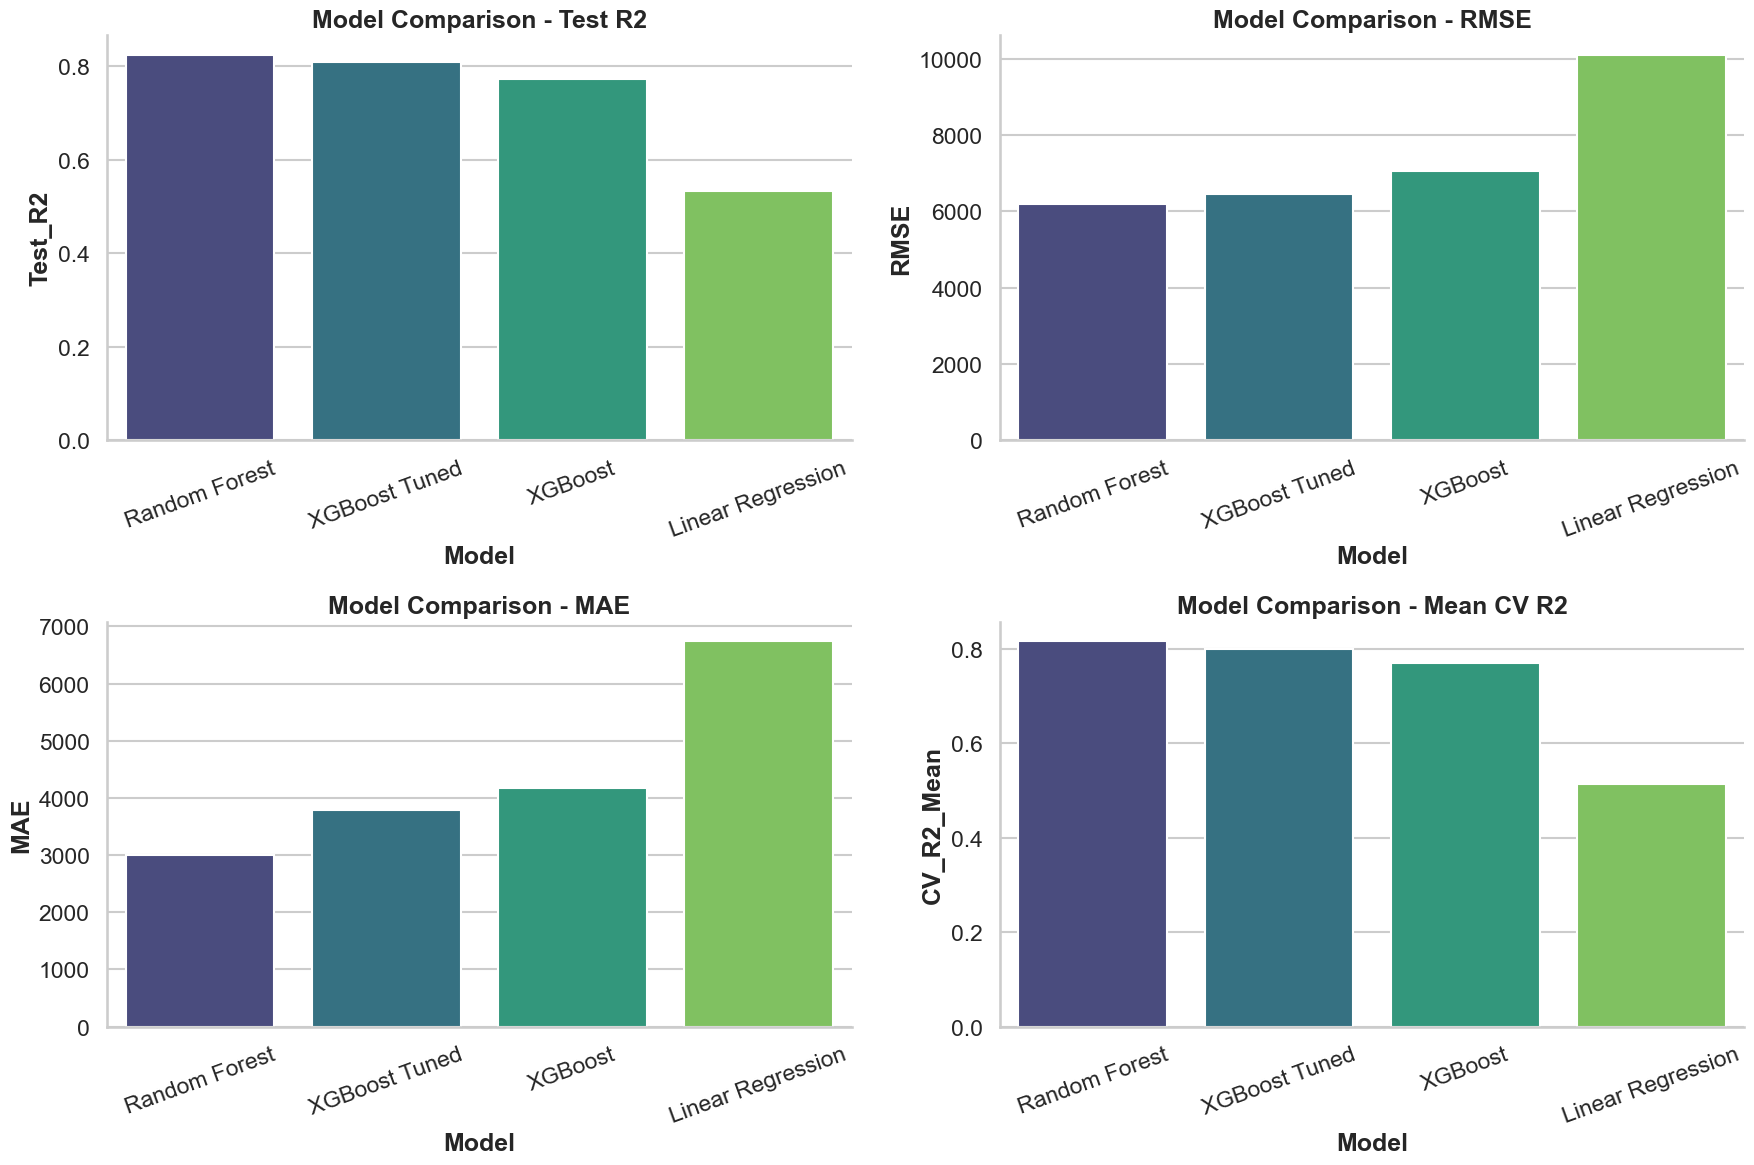

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
comparison_palette = sns.color_palette('viridis', len(full_regression_results_df))

sns.barplot(data=full_regression_results_df, x='Model', y='Test_R2', palette=comparison_palette, ax=axes[0, 0])
axes[0, 0].set_title('Model Comparison - Test R2')
axes[0, 0].tick_params(axis='x', rotation=20)

sns.barplot(data=full_regression_results_df, x='Model', y='RMSE', palette=comparison_palette, ax=axes[0, 1])
axes[0, 1].set_title('Model Comparison - RMSE')
axes[0, 1].tick_params(axis='x', rotation=20)

sns.barplot(data=full_regression_results_df, x='Model', y='MAE', palette=comparison_palette, ax=axes[1, 0])
axes[1, 0].set_title('Model Comparison - MAE')
axes[1, 0].tick_params(axis='x', rotation=20)

sns.barplot(data=full_regression_results_df, x='Model', y='CV_R2_Mean', palette=comparison_palette, ax=axes[1, 1])
axes[1, 1].set_title('Model Comparison - Mean CV R2')
axes[1, 1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()


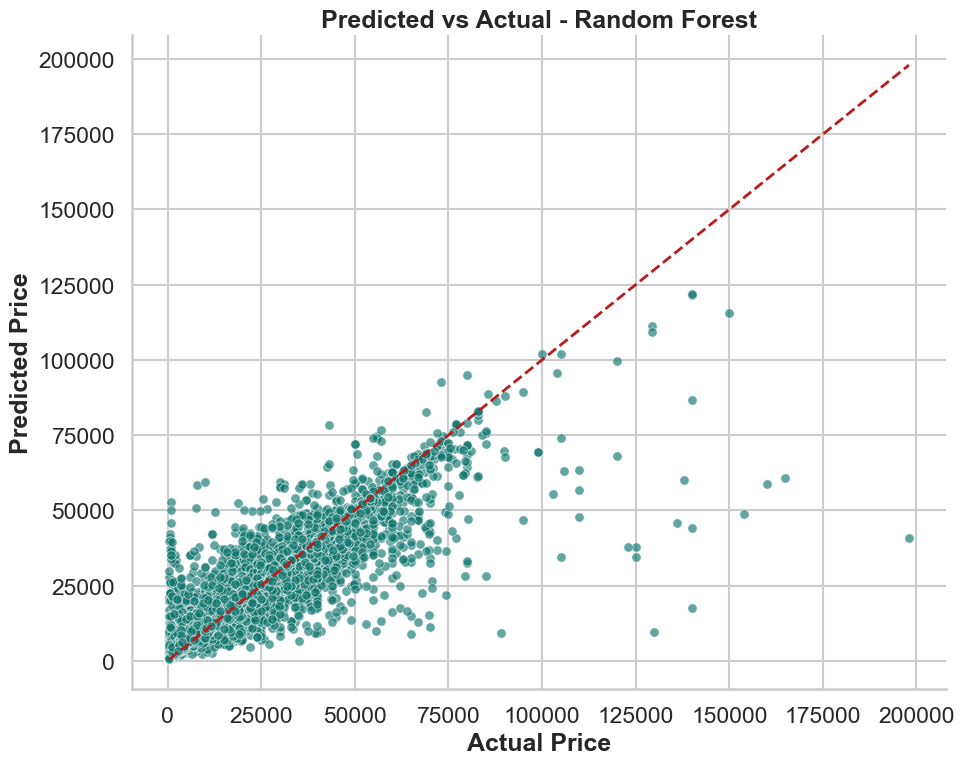

In [23]:
plot_frame = best_regression_predictions.copy()

plt.figure(figsize=(10, 8))
sns.scatterplot(data=plot_frame, x='Actual', y='Predicted', s=45, alpha=0.65, color='#0f766e')
bounds = [plot_frame[['Actual', 'Predicted']].min().min(), plot_frame[['Actual', 'Predicted']].max().max()]
plt.plot(bounds, bounds, linestyle='--', color='#b91c1c', linewidth=2)
plt.title(f'Predicted vs Actual - {best_regression_model_name}')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.tight_layout()
plt.show()


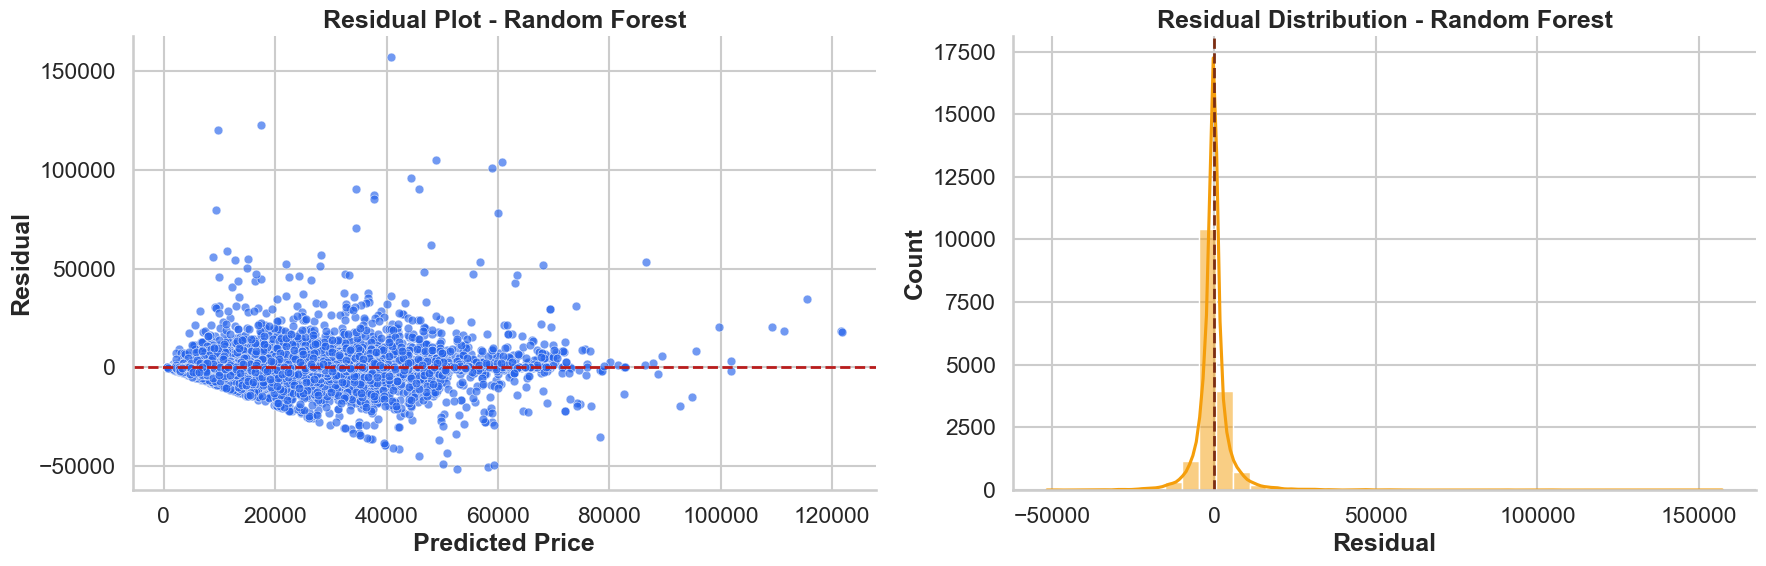

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.scatterplot(data=plot_frame, x='Predicted', y='Residual', s=40, alpha=0.65, color='#2563eb', ax=axes[0])
axes[0].axhline(0, linestyle='--', color='#b91c1c', linewidth=2)
axes[0].set_title(f'Residual Plot - {best_regression_model_name}')
axes[0].set_xlabel('Predicted Price')
axes[0].set_ylabel('Residual')

sns.histplot(plot_frame['Residual'], bins=40, kde=True, color='#f59e0b', ax=axes[1])
axes[1].axvline(0, linestyle='--', color='#7c2d12', linewidth=2)
axes[1].set_title(f'Residual Distribution - {best_regression_model_name}')
axes[1].set_xlabel('Residual')

plt.tight_layout()
plt.show()


### 8. Feature Importance

Feature importance helps answer an important reviewer question: **what is driving the predictions?**

Why we check it:
- It improves interpretability.
- It helps verify whether the model is learning sensible business patterns.
- It can reveal if the model is relying too much on a suspicious feature.

Example:
- If `vehicle_age`, `odometer`, and `manufacturer` are important, that makes business sense.
- If a strange proxy variable dominates, we should investigate.

How it helps decision making:
- Dealers can understand what most influences resale value.
- Analysts can decide which features are worth collecting more carefully.
- It can guide future feature engineering.

Important caution:
- Feature importance does not prove causation.
- It tells us what the model found useful, not necessarily what truly causes price.


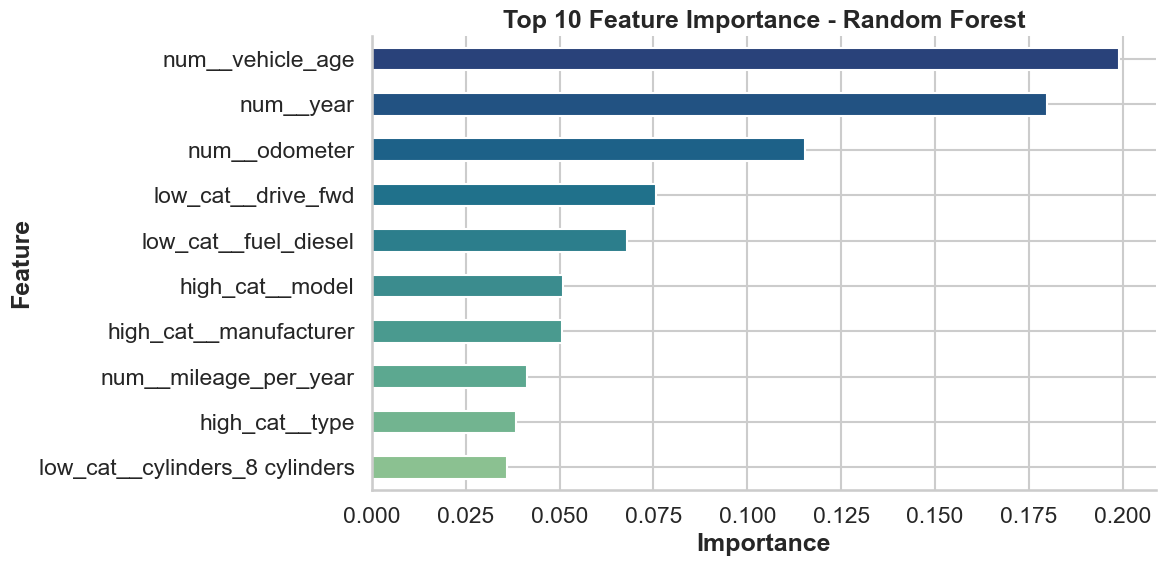

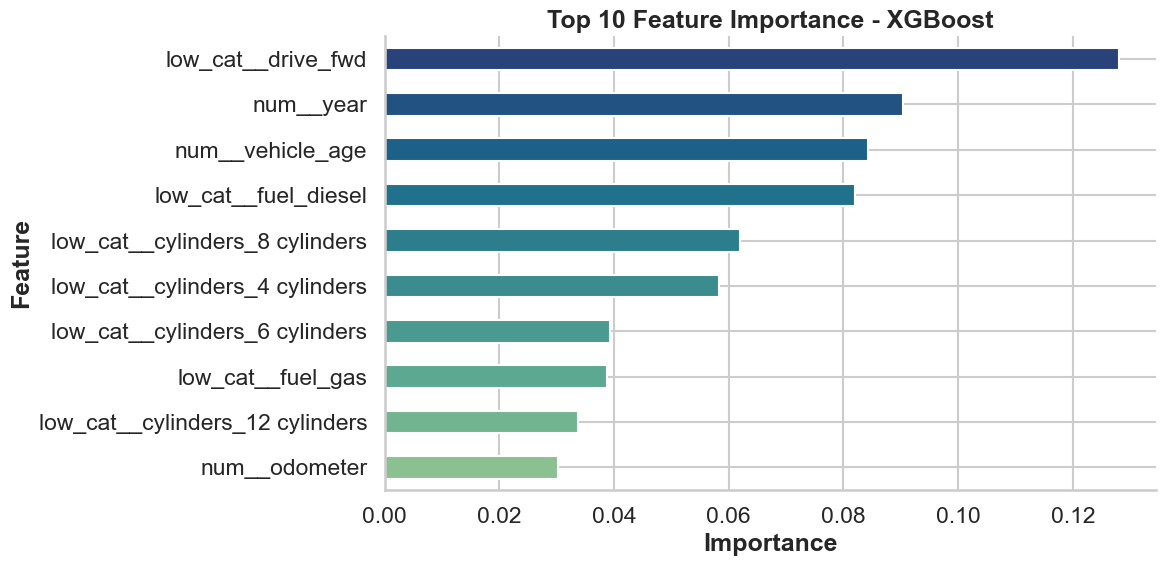

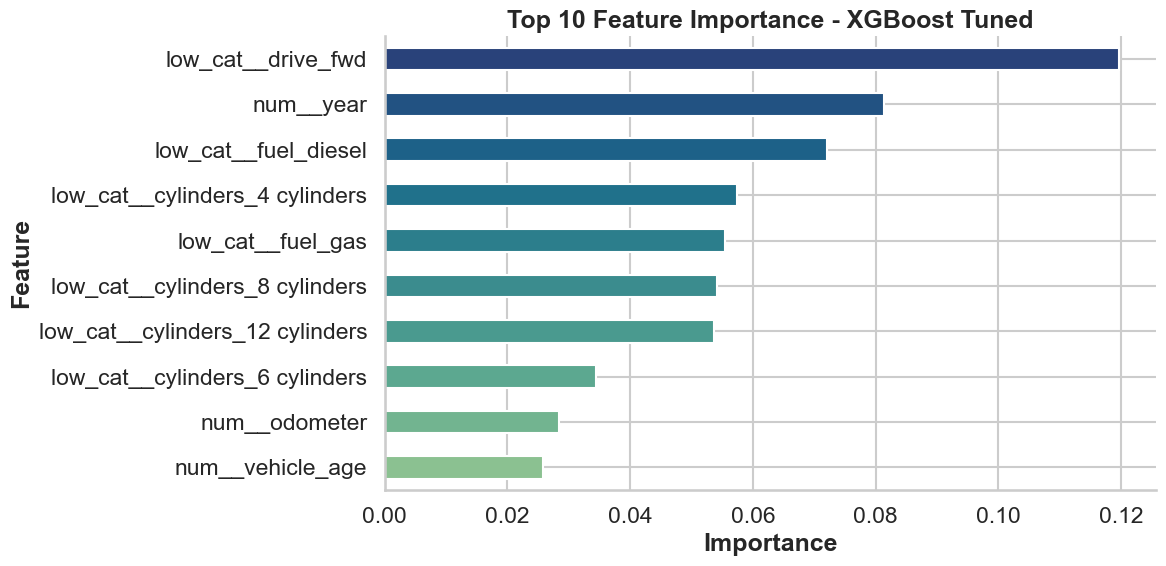

In [25]:
for model_name in ['Random Forest', 'XGBoost', 'XGBoost Tuned']:
    if model_name in regression_artifacts:
        plot_feature_importance(model_name, regression_artifacts[model_name]['pipeline'], top_n=10)


### 10. Error Analysis

Looking only at average metrics is not enough. A strong ML review always checks where the model fails.

Why wrong predictions matter:
- The biggest mistakes often reveal missing features, unusual vehicles, noisy records, or data quality issues.
- They show where the model is weak in practice.

Examples of useful insights:
- Luxury cars may be underpriced because trim details are missing.
- Rare vehicle types may be predicted poorly because the model has little training data for them.
- Extreme mileage or modified vehicles may behave differently from normal listings.

How error analysis improves the model:
- It suggests new features to engineer.
- It helps detect bad data.
- It can motivate separate models for different market segments.


In [26]:
worst_predictions = best_regression_predictions.sort_values('Absolute_Error', ascending=False).head(10).reset_index(drop=True)
display(worst_predictions.style.format({
    'Actual': '{:,.2f}',
    'Predicted': '{:,.2f}',
    'Residual': '{:,.2f}',
    'Absolute_Error': '{:,.2f}',
    'Percentage_Error': '{:.2f}%',
}))


,Actual,Predicted,Residual,Absolute_Error,Percentage_Error
0,"197,999.00","40,820.45","157,178.55","157,178.55",79.38%
1,"140,000.00","17,441.65","122,558.35","122,558.35",87.54%
2,"129,888.00","9,727.89","120,160.11","120,160.11",92.51%
3,"153,880.00","48,963.98","104,916.02","104,916.02",68.18%
4,"164,900.00","60,806.81","104,093.19","104,093.19",63.13%
5,"159,991.00","58,903.98","101,087.02","101,087.02",63.18%
6,"139,950.00","44,305.95","95,644.05","95,644.05",68.34%
7,"124,988.00","34,604.74","90,383.26","90,383.26",72.31%
8,"136,000.00","45,835.14","90,164.86","90,164.86",66.30%
9,"124,988.00","37,683.99","87,304.01","87,304.01",69.85%
